# Half-Life of Mean Reversion

This notebook estimates the half-life of mean reversion from a simple regression of $\Delta y_t$ on $y_{t-1}$.

The working approximation is:

$$
\Delta y_t = \lambda y_{t-1} + c + \varepsilon_t,
$$

and the half-life is:

$$
\text{half-life} = -\frac{\log 2}{\lambda}.
$$

This only makes economic sense when $\lambda < 0$.

In [1]:
import warnings

import numpy as np
import pandas as pd
import vectorbt as vbt

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")

/opt/conda/lib/python3.11/site-packages/apscheduler/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


In [2]:
# Daily crypto data from Binance via CCXT
symbol = "BTC/USDT"
timeframe = "1d"
start = "2022-01-01 UTC"
end = "2024-12-31 UTC"

data = vbt.CCXTData.download(
    symbol,
    exchange="binance",
    timeframe=timeframe,
    start=start,
    end=end,
    show_progress=True,
)

close = data.get("Close").dropna()
log_price = np.log(close)

# Use a detrended series so the half-life describes pullback to a local mean
# rather than the raw non-stationary crypto price itself.
rolling_mean = log_price.rolling(30).mean()
mean_reverting_series = (log_price - rolling_mean).dropna()

mean_reverting_series.tail()

0it [00:00, ?it/s]

Open time
2024-12-26 00:00:00+00:00   -0.029690
2024-12-27 00:00:00+00:00   -0.044846
2024-12-28 00:00:00+00:00   -0.034167
2024-12-29 00:00:00+00:00   -0.049393
2024-12-30 00:00:00+00:00   -0.058264
Freq: D, Name: Close, dtype: float64

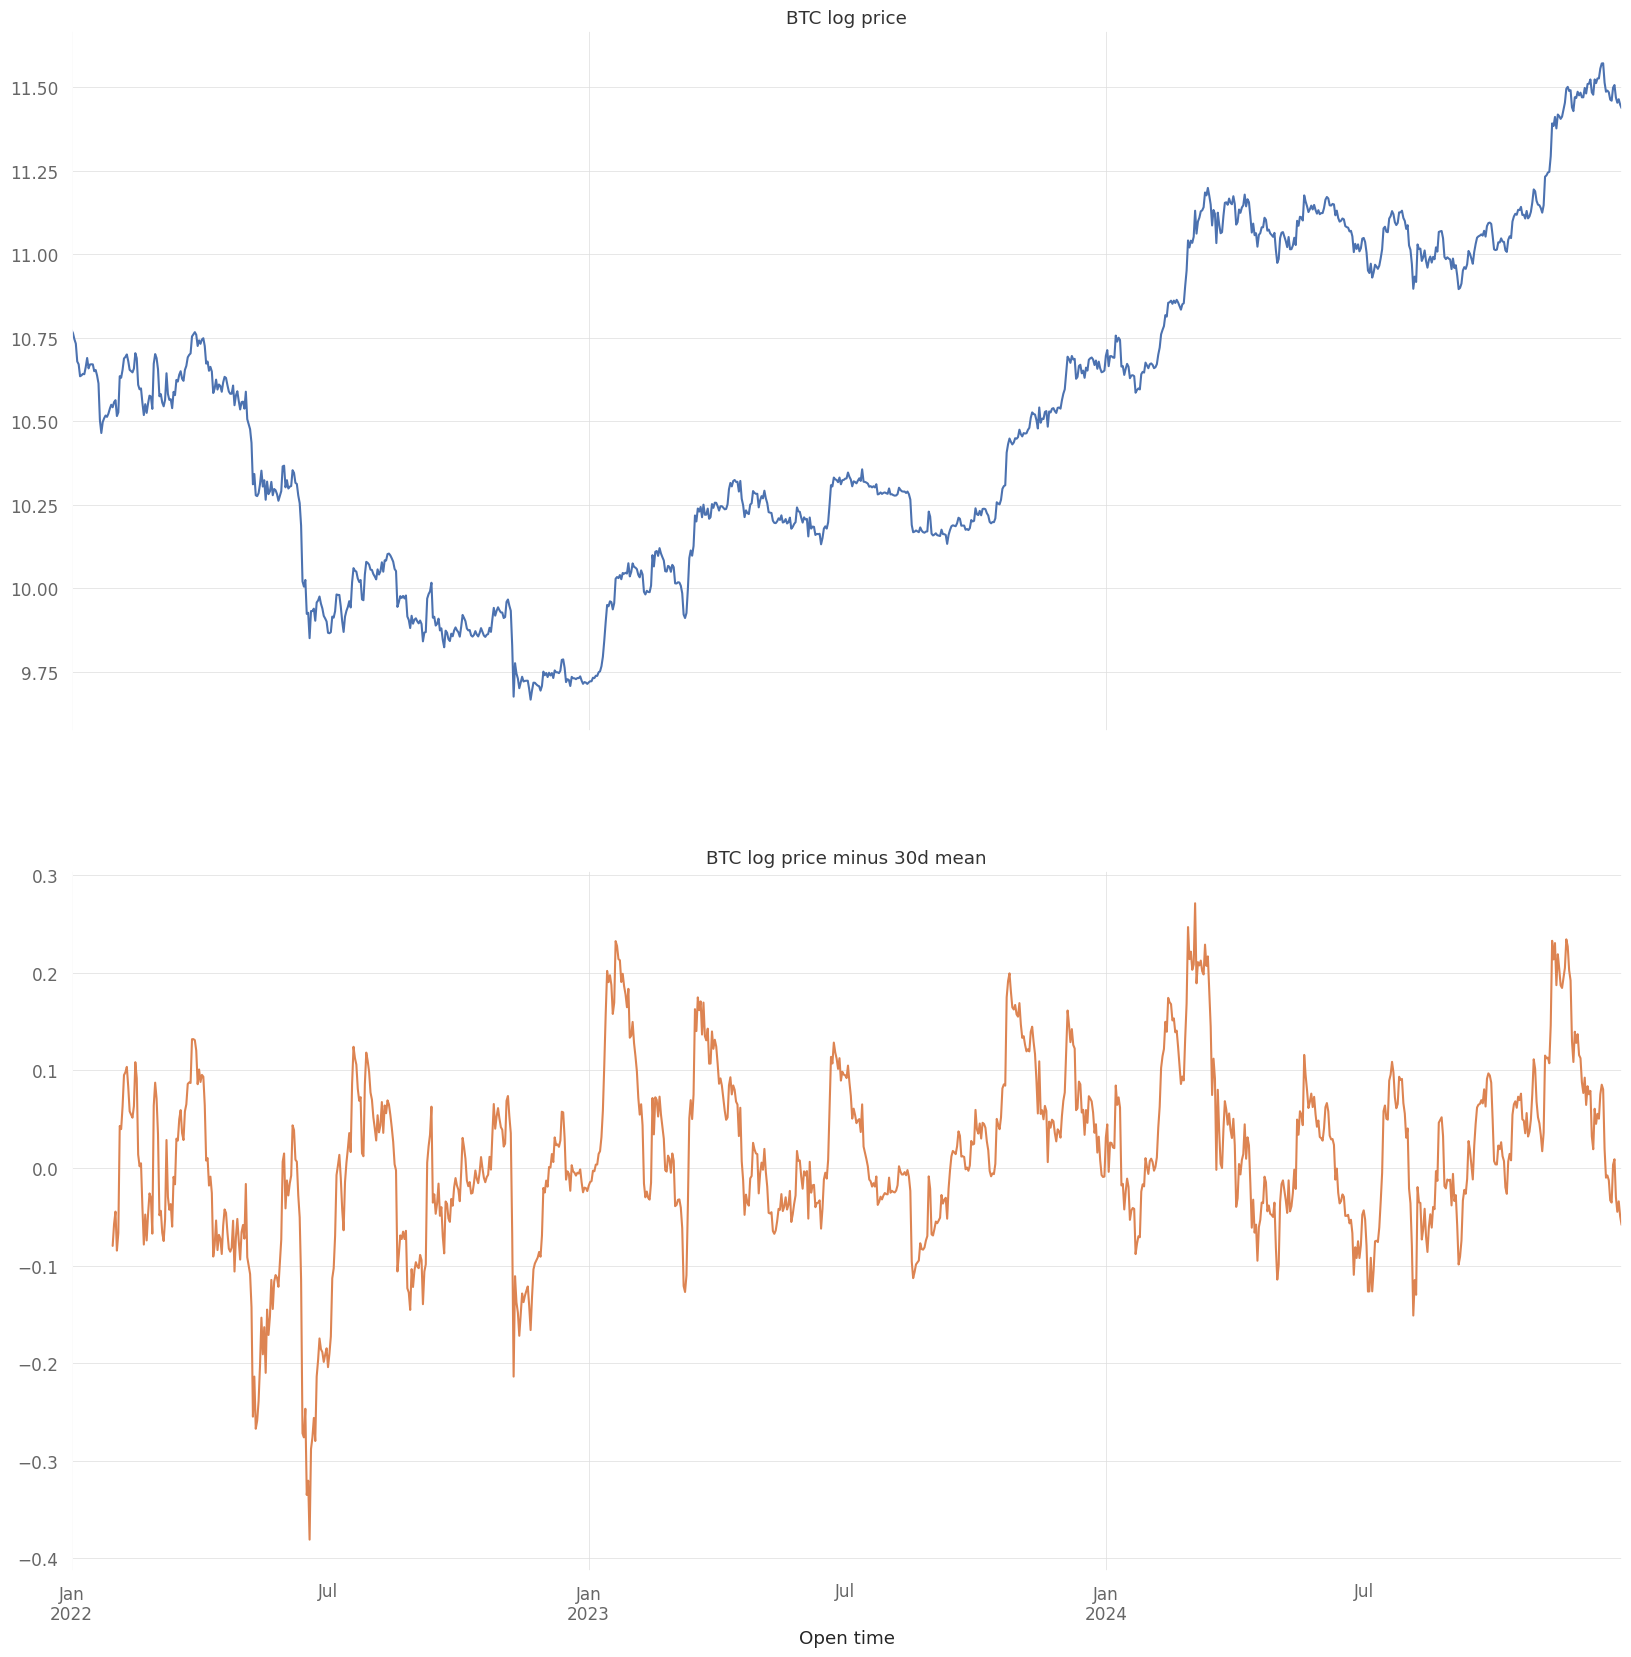

In [4]:
pd.concat(
    {
        "BTC log price": log_price,
        "BTC log price - 30d mean": mean_reverting_series,
    },
    axis=1,
).plot(
    subplots=True,
    figsize=(20, 20),
    title=["BTC log price", "BTC log price minus 30d mean"],
    layout=(2, 1),
    legend=False,
);

In [5]:
def estimate_half_life(series: pd.Series) -> tuple[pd.Series, pd.DataFrame]:
    y = pd.Series(series).dropna()
    lagged = y.shift(1)
    delta = y.diff()

    reg_df = pd.DataFrame({"lagged": lagged, "delta": delta}).dropna()
    x = np.column_stack([np.ones(len(reg_df)), reg_df["lagged"].to_numpy()])
    y_dep = reg_df["delta"].to_numpy()

    intercept, lambda_hat = np.linalg.lstsq(x, y_dep, rcond=None)[0]

    if lambda_hat >= 0:
        half_life = np.nan
        verdict = "not mean reverting"
    else:
        half_life = -np.log(2) / lambda_hat
        verdict = "mean reverting"

    summary = pd.Series(
        {
            "intercept": intercept,
            "lambda": lambda_hat,
            "half_life_days": half_life,
            "verdict": verdict,
            "observations": len(reg_df),
        }
    )
    return summary, reg_df

In [6]:
half_life_summary, reg_df = estimate_half_life(mean_reverting_series)

half_life_df = half_life_summary.to_frame(name="value")
half_life_df

,value
intercept,0.000627
lambda,-0.048916
half_life_days,14.170244
verdict,mean reverting
observations,1065


In [7]:
if pd.notna(half_life_summary["half_life_days"]):
    half_life_days = float(half_life_summary["half_life_days"])
    lookback_df = pd.DataFrame(
        {
            "rule": [
                "half-life",
                "rounded half-life",
                "2 x half-life",
            ],
            "days": [
                half_life_days,
                round(half_life_days),
                round(2 * half_life_days),
            ],
        }
    )
else:
    lookback_df = pd.DataFrame(
        {
            "rule": ["half-life unavailable"],
            "days": [np.nan],
        }
    )

lookback_df

,rule,days
0,half-life,14.170244
1,rounded half-life,14.000000
2,2 x half-life,28.000000


## Interpretation

Half-life turns the regression coefficient into trading time. A negative `λ` gives a finite half-life. A very small negative `λ` gives a very long half-life, which usually means the pullback is too slow to be useful for a short-horizon strategy.